In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [26]:
df=pd.read_csv('cardio_train.csv')
df['age'] = (df['age'] / 365.25).astype(int)

In [27]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62,110,80,1,1,0,0,1,0
1,1,55,1,156,85,140,90,3,1,0,0,1,1
2,2,51,1,165,64,130,70,3,1,0,0,0,1
3,3,48,2,169,82,150,100,1,1,0,0,1,1
4,4,47,1,156,56,100,60,1,1,0,0,0,0


In [29]:
df.dtypes

id             int64
age            int64
gender         int64
height         int64
weight         int64
ap_hi          int64
ap_lo          int64
cholesterol    int64
gluc           int64
smoke          int64
alco           int64
active         int64
cardio         int64
dtype: object

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           70000 non-null  int64
 1   age          70000 non-null  int64
 2   gender       70000 non-null  int64
 3   height       70000 non-null  int64
 4   weight       70000 non-null  int64
 5   ap_hi        70000 non-null  int64
 6   ap_lo        70000 non-null  int64
 7   cholesterol  70000 non-null  int64
 8   gluc         70000 non-null  int64
 9   smoke        70000 non-null  int64
 10  alco         70000 non-null  int64
 11  active       70000 non-null  int64
 12  cardio       70000 non-null  int64
dtypes: int64(13)
memory usage: 6.9 MB


In [31]:
df.shape

(70000, 13)

In [32]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,52.803257,1.349571,164.359229,74.205543,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,6.762462,0.476838,8.210126,14.395829,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,29.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,64.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


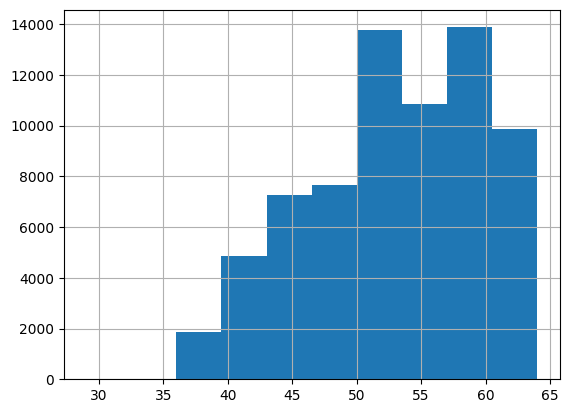

In [35]:
df['age'].hist()
plt.show()

In [37]:

df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df['gender'].unique()

array([2, 1])

In [40]:
df['weight'].describe()

count    70000.000000
mean        74.205543
std         14.395829
min         10.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64

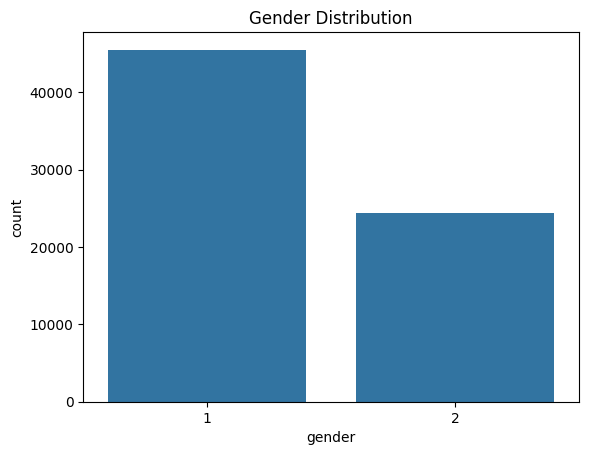

In [41]:
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

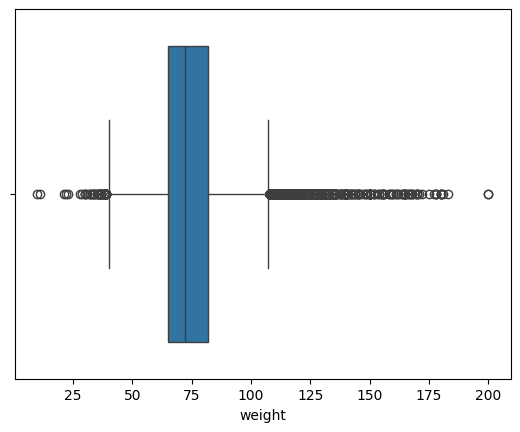

In [42]:
sns.boxplot(x=df['weight'])
plt.show()

In [43]:
Q1 = df['weight'].quantile(0.25)
Q3 = df['weight'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['weight'] >= lower) & (df['weight'] <= upper)]

In [44]:
df['weight'].describe()

count    68181.000000
mean        73.081650
std         12.437402
min         40.000000
25%         65.000000
50%         72.000000
75%         81.000000
max        107.000000
Name: weight, dtype: float64

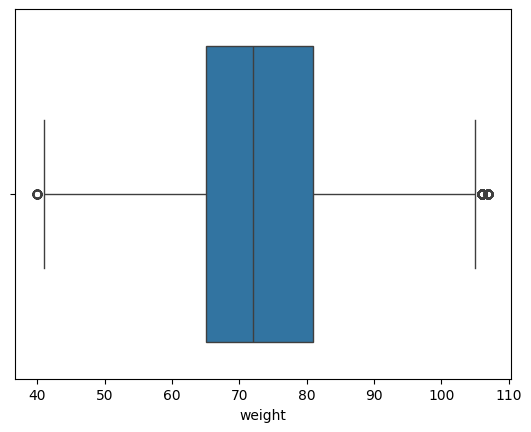

In [45]:
sns.boxplot(x=df['weight'])
plt.show()

In [46]:
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [47]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [48]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.600000,2,0.579487,0.328358,0.016079,0.013550,1,1,0,0,1,0
1,1,0.742857,1,0.517949,0.671642,0.017934,0.014453,3,1,0,0,1,1
2,2,0.628571,1,0.564103,0.358209,0.017316,0.012647,3,1,0,0,0,1
3,3,0.542857,2,0.584615,0.626866,0.018553,0.015357,1,1,0,0,1,1
4,4,0.514286,1,0.517949,0.238806,0.015461,0.011743,1,1,0,0,0,0
